# Will a financial AI agent reduce risk in a market crisis?

This runs [FinRobot](https://github.com/AI4Finance-Foundation/FinRobot)
inside [Tradefloor](https://tradefloor.dev), copies the market it is
trading, and drops a liquidity crisis on one copy.

Twenty-four real companies loaded from SEC filings, fifty million dollars,
twenty shared trading days, then one checkpoint and two arms. One arm
continues unchanged. The other runs under `liquidity_crisis`, a scenario
that ships in the Tradefloor wheel: quoted depth to 40%, volatility
doubled, and a stated assumption that credit widens fifty basis points.
Both arms run twenty more days under the same agent and the same cadence.

The agent is never told there is a crisis. No word in its observation says
so. It reads a volatility number, a credit spread, and a book with 40% of
its usual depth.

**What it did.** Mean gross exposure of 0.64 in the crisis arm against 0.86
in control. The agent's own contribution -- exposure measured immediately
before and after its fills, at the same prices -- is -0.13 in the crisis
arm and +0.12 in control. The sign flips, so this is the agent trading and
not prices moving.

**Check one, the resample.** Ask each arm the same fork-step question eight
times. Eight identical calls per arm, with every byte of the input the
same, so the spread between the answers is the agent's own. Re-asking the
exact same fork-step question produced substantial variation. The first
decision alone did not give us a clean answer, and the ratios it produces
are in the notebook rather than in the headline.

**Check two, replication.** Run the whole experiment four times. The crisis
arm carried less exposure in three of them. The gap averages 1.21 times the
between-run spread.

Two observations about the fourth run, without reading more into them. The
crisis values occupy a narrower range than the control values, 0.627 to
0.725 against 0.637 to 0.916. And run 4's crisis figure of 0.646 sits among
the other crisis figures, while its control figure of 0.637 sits well below
the other three controls. We do not know why the model produced that
trajectory.

Getting to that needs a deterministic market, a fork that leaves the arms
verifiably identical, a way to re-ask one question, and a way to re-run the
whole thing. This notebook does all four in a few seconds, because the
agent's real responses were recorded once and are replayed here.

## Scope of the claim

Real company fundamentals are the initial conditions. EPS, book value per
share, revenue growth, share count and sector come from SEC EDGAR filings.
Every price, spread, fill and order-book state after step zero is generated
by Tradefloor under the `pt-v16` preset.

Nothing here predicts or describes the behaviour of any real security. The
tickers are real companies and the market is not.

Three separate bodies of evidence appear below, and they answer different
questions. One canonical recorded trajectory per arm carries the detailed
path analysis. Eight identical fork-step calls per arm measure how much the
agent varies when asked one question repeatedly. Four complete live
replications of the whole experiment provide separate model trajectories
for checking the direction.

The days inside one trajectory are not independent samples of anything.
Where a number cannot carry a claim, the notebook says so rather than
rounding it into one.

The path lookup in the next cell exists so the notebook opens from
anywhere: a notebook has no `__file__`, and a reader who starts Jupyter at
the repository root is one level above `experiment.py`. Everything after
it is the experiment.

In [1]:
import sys
from pathlib import Path

HERE = Path("examples/experiments/liquidity-crisis")
CANDIDATES = (Path.cwd(), *Path.cwd().parents)
STUDY = next(
    (d for base in CANDIDATES
     for d in (base, base / HERE)
     if (d / "experiment.py").is_file()), None)
if STUDY is None:
    raise RuntimeError(
        "start Jupyter inside the tradefloor repository, or inside "
        f"{HERE}")
sys.path.insert(0, str(STUDY))

import experiment as ex

import tradefloor as tf
from tradefloor.counterfactual import World, agree, compare
from tradefloor.integrations.finrobot import (
    DecisionError, FinRobotAdapter, Transcript, parse)

print(f"tradefloor {tf.__version__}, preset {ex.PRESET}, seed {ex.SEED}")

tradefloor 0.6.1, preset pt-v16, seed 4242


## The universe

Twenty-four companies, two from each of the twelve sectors Tradefloor
models, drawn from a frozen EDGAR snapshot.

Drawn deterministically. Each ticker is ranked inside its sector by
`sha256(salt + "|" + ticker)` under a salt fixed before the run, and the
lowest two are taken. The rule depends on the ticker string and nothing
else, so it cannot be steered by an outcome, and a reader can recompute any
line by hand.

In [2]:
snapshot = ex.load_snapshot()
small = ex.subset(snapshot)
instruments = ex.universe(small)
fundamentals = ex.fundamentals(small)

print(f"drawn from {len(snapshot.rows)} filers, snapshot {snapshot.hash[:16]}")
print(f"subset of {len(small.rows)}, hash {small.hash[:16]}")
print()
for row in small.rows:
    print(f"  {row['ticker']:<6} {row['sector']:<24} "
          f"eps {row['eps']:>7.2f}   key {ex.universe_key(row['ticker'])[:8]}")

drawn from 421 filers, snapshot a409d29efbe9f5d0
subset of 24, hash d39a0a4c3cfad023

  ADM    consumer_staples         eps    2.23   key 1b5d9e49
  AKAM   industrials              eps    3.07   key 04b5553c
  AMD    technology               eps    2.65   key 0477db21
  EXPE   transportation           eps    9.81   key 26a5d6d8
  EXR    real_estate              eps    4.59   key 068521d4
  FANG   energy                   eps    5.73   key 371365bd
  GLW    materials                eps    1.83   key 01c5473f
  IBM    technology               eps   11.17   key 06ba7c3b
  INCY   healthcare               eps    6.41   key 1a9b066a
  LNT    utilities                eps    3.14   key 0baca14b
  MAA    real_estate              eps    3.78   key 031952fd
  MOS    materials                eps    1.70   key 0e256096
  MRNA   healthcare               eps   -7.26   key 0517784e
  NSC    transportation           eps   12.75   key 004e5fc2
  OMC    industrials              eps   -0.27   key 02fed7d9

## The agent

A real FinRobot `SingleAssistant`, driven through autogen, the same class
FinRobot ships. It is handed an observation as text, and it answers with a
JSON portfolio decision that Tradefloor validates and executes.

The observation is an allowlist, written out field by field. Fair value,
the factor attribution of every price move, each company's mispricing and
the macro path the run has not reached are all on the simulator's side of
the line. The agent sees what a trader in this market could see.

Below is the agent's own record of what it was sent. The macro block is the
part this experiment moves.

In [3]:
transcript = Transcript.load(ex.FIXTURE)
print(f"recorded run: {len(transcript)} interactions, "
      f"{transcript.meta.get('model')} at temperature "
      f"{transcript.meta.get('temperature')}")

sample = transcript.entries[0]["prompt"]
print()
print(sample[:sample.index("Assets")].rstrip())

recorded run: 60 interactions, claude-sonnet-4-5-20250929 at temperature 0.0

SIMULATED MARKET

Day 0, decision step 0.

Macro
-----
federal_funds_rate     0.0400
corporate_bond_yield   0.0550
vix                    15.0000
inflation_rate         0.0200
cycle                  expansion


### When a model answer is not a decision

At temperature 0 a model still sometimes returns output the market cannot
execute. The earlier recording of this experiment contains one: a
`rationale` attached to an individual action, which Tradefloor refuses
rather than dropping the unknown field and executing a trade the agent
believed was conditioned on something else.

`World(on_refusal="skip")` costs the agent that decision and counts it. No
repair, no retry, no trade. The count is kept apart from the market-side
`refused`, because an agent that could not format an answer and a market
that rejected an order are different failures.

The counts are published either way, so a reader can tell an agent that
never stumbled from a report that never counted.

This experiment is where `on_refusal` came from: the first live run of it
died on call 36 of 60, and everything paid for up to that point went with
it.

In [4]:
def unusable(entries):
    """Responses this market has no execution path for."""
    out = []
    for entry in entries:
        try:
            parse(entry["response"])
        except DecisionError as exc:
            out.append((entry, exc))
    return out


bad = unusable(transcript.entries)
print(f"this recording: {len(bad)} of {len(transcript)} responses unusable")

# The one that prompted the refusal policy, from the earlier recording of
# this experiment. Shown because a rate of one in eighty is worth seeing
# rather than being told.
older = Transcript.load(ex.LEGACY_FIXTURE)
was_bad = unusable(older.entries)
print(f"the earlier recording: {len(was_bad)} of {len(older)}")
print()
if was_bad:
    entry, exc = was_bad[0]
    print(str(exc)[:200])
    print()
    print(entry["response"][:380].rstrip() + " ...")

this recording: 0 of 60 responses unusable
the earlier recording: 1 of 80

action 0 carries rationale, which this market has no execution path for. An action is symbol, side, quantity and nothing else. Ignoring the field would execute a trade the agent conditioned on somethi

Looking at the current portfolio and market conditions:

**Market Context:**
- Expansion cycle with moderate VIX (15.55)
- Healthy macro environment (low rates, moderate inflation)
- Portfolio is well-diversified with 95% gross exposure

**Portfolio Analysis:**
- Strong positions in financials (TRV, SYF), technology (AMD, IBM), and telecom (TMUS)
- Recent underperformers: AMD ( ...


## Twenty shared days

One agent, one market, one decision a day, and no fork yet.

In [5]:
agent = FinRobotAdapter(mode="replay", transcript=transcript,
                        fundamentals=fundamentals, objective=ex.OBJECTIVE,
                        every=ex.DECISION_EVERY, arm="shared")

world = World(seed=ex.SEED, universe=instruments, agent=agent,
              pins=ex.BASE_PINS, cash=ex.CASH,
              steps_per_day=ex.STEPS_PER_DAY,
              ticks_per_step=ex.TICKS_PER_STEP,
              model=ex.PRESET, label="shared",
              on_refusal="skip")
world.run(days=ex.WARMUP_DAYS)
mark = world.checkpoint("before the interventions")

print(f"after {world.day} days: ${world.net_worth():,.0f}, "
      f"{world.portfolio.leverage(world.engine):.2f}x gross")
print(f"market digest {world.digest()[:32]}...")
print(f"{len(mark.log):,} operations in the checkpoint")

after 20 days: $49,395,207, 0.79x gross
market digest 51cce55323de23c4bfca10d77136d6a5...
180 operations in the checkpoint


## One checkpoint and two arms

`fork` produces independent continuations, with separate engines,
separate portfolios and separate agents, so driving one cannot perturb
another.

`agree` then checks that they really are identical rather than merely
similar. Nine checks, every one read back off the two objects: the market
columns, the prices, the order book, the generator position, the macro
chain, the whole engine state, the portfolio, the agent's own state and the
shared history.

Every pair is checked, not one. Two arms make one pair; a five-arm
decomposition later in this notebook makes ten, and checking one of them
would leave nine unverified.

In [6]:
names = list(ex.ARMS)
worlds = dict(zip(names, world.fork(*names)))
for label, arm in worlds.items():
    arm.agent.arm = label

for i, left in enumerate(names):
    for right in names[i + 1:]:
        found = agree(worlds[left], worlds[right])
        print(f"{left:>9} vs {right:<9} "
              f"{'identical' if found.identical else 'DIFFERENT'}"
              f"   {len(found.checks)} checks")
        assert found.identical, found.differences

  control vs crisis    identical   9 checks


## The scenario

One branch gets a Tradefloor scenario. The other gets nothing.

A scenario is a small, explicit description of what changes in the market,
read off disk rather than written into the experiment. It separates what it
asserts happened from what it merely assumes followed, and it carries a
fingerprint, so two people can check they ran the same one.

This one is `liquidity_crisis`, which ships in the Tradefloor wheel. Quoted
depth falls to 40% and volatility doubles for twenty-five days; alongside
them the file states one ASSUMPTION, that credit widens fifty basis points.
Nothing in the simulator derives that third number, which is exactly why it
sits under a different heading.

The file here differs from the packaged one in a single field. Every
packaged scenario fires `at: 50`, because they are written for a single
market with fifty days of warmup, and `World.apply` rebases `at` onto the
day it is applied on -- so handing the packaged file to an arm forked on day
20 would fire it on day 70. Fifty post-fork days before the shock means
fifty days of the two arms drifting apart on nothing but the agent
answering the same question two ways, and the crisis would then land on two
markets that are no longer comparable. So `at: 0`, and nothing else.

In [7]:
scenario = ex.load_scenario()
packaged = tf.Scenario.load(ex.PACKAGED_SCENARIO)


def shape(s):
    return sorted((i.target, i.operation, i.value, i.role)
                  for i in s.interventions)


print(f"{scenario.name}  {scenario.fingerprint}")
print(f"rebased from {packaged.name}  {packaged.fingerprint}")
print(f"every shock identical to the packaged file: "
      f"{shape(scenario) == shape(packaged)}")
print()
for item in scenario.interventions:
    print(f"  {item.role:<12}{item.target:<24}"
          f"{item.operation} {item.value}   "
          f"days {item.at} to {item.last_day}")

liquidity_crisis_at_fork  sha256:3b13efc30d25f0034b7d7db895cdf9ab401fb04a16b06cc291f792b59d424d61
rebased from liquidity_crisis  sha256:a8eb4bbc679fdfac243930456768fb941da14efd7ab653bac373ffded3531a98
every shock identical to the packaged file: True

  shock       market.liquidity        multiply 0.4   days 0 to 24
  shock       macro.vix               multiply 2.0   days 0 to 24
  transmissionmacro.corporate_yield   add 0.005   days 0 to 24


`market.liquidity` is the one target here that is not a macro field, and it
is the only lever in Tradefloor that touches execution. It scales the volume
column the market maker quotes off, so every ladder level thins and the same
trade costs more to put on.

It also reaches the agent, which took a fix to be true: the volume figure in
the observation and the order cap the agent is clipped against were read
once at construction and never again, so under a depth shock the book
thinned and the agent went on seeing -- and being allowed -- the pre-crisis
size. In a market with 40% of the depth.

In [8]:
for label, treatment in ex.ARMS.items():
    print(f"{label:>9}  {ex.treat(worlds[label], treatment)}")

for arm in worlds.values():
    arm.run(days=ex.BRANCH_DAYS)
print(f"\nboth arms ran {ex.BRANCH_DAYS} days")

  control  none
   crisis  scenario liquidity_crisis_at_fork sha256:3b13efc30d25



both arms ran 20 days


### The size of the manipulation

This is the whole experimental manipulation, and it is small enough to
print. Every other line of the prompt is byte-identical across the arms.

Compare it with experiment 001, which moved a policy rate by 200 basis
points over 421 companies: two lines of 376, and the agent barely moved. A
rate shock is a LEVEL shift, and an observation carrying prices and
five-day returns shows a one-off repricing for exactly one return window.
After that the only trace is two decimal places.

In [9]:
step = worlds[ex.CONTROL_ARM].fork_step
prompts = {n: next(e["prompt"] for e in worlds[n].agent.record
                   if e["step"] == step) for n in names}
base = prompts[ex.CONTROL_ARM].splitlines()

for name in ex.TREATMENTS:
    lines = prompts[name].splitlines()
    diff = [(a, b) for a, b in zip(base, lines) if a != b]
    print(f"{name}: {len(diff)} of {len(base)} lines differ")
    for a, b in diff[:6]:
        print(f"    - {a.strip()}")
        print(f"    + {b.strip()}")
    if len(diff) > 6:
        print(f"    ... and {len(diff) - 6} more, all bid/ask, one cent "
              "wider from the VIX move")
    print()

crisis: 72 of 372 lines differ
    - corporate_bond_yield   0.0550
    + corporate_bond_yield   0.0600
    - vix                    16.5121
    + vix                    33.0243
    - bid / ask            45.84 / 45.86
    + bid / ask            45.83 / 45.87
    - avg daily volume     2,406,009
    + avg daily volume     962,404
    - max order this step  48,120 shares
    + max order this step  19,248 shares
    - bid / ask            51.26 / 51.32
    + bid / ask            51.25 / 51.33
    ... and 66 more, all bid/ask, one cent wider from the VIX move



## The agent's response in the recorded run

Gross exposure, per decision, in each arm. Gross exposure rather than P&L:
after the fork the arms trade different markets, so comparing their returns
measures the market as much as the agent.

Read this as one run rather than as the result, because two checks follow
it and one of them takes half of it away.

In [10]:
series = ex.exposure_series(worlds)
bands = ex.bands(series, names)
order = ex.ordering(series, names)

print(f"{'day':>4}" + "".join(f"{n:>12}" for n in names) + "   risk words")
for item in series:
    marks = "".join("Y" if item[f"risk_{n}"] else "." for n in names)
    print(f"{item['day']:>4}"
          + "".join(f"{item[f'exposure_{n}']:>12.2f}" for n in names)
          + f"   {marks}")

print()
for name in names:
    row = bands[name]
    print(f"{name:<10} mean gross exposure {row['mean_exposure']:.3f}   "
          f"risk language {row['risk_language']}/{row['decisions']}")

 day     control      crisis   risk words
  20        0.77        0.77   .Y
  21        0.82        0.77   YY
  22        0.82        0.69   YY
  23        0.86        0.69   ..
  24        0.86        0.66   YY
  25        0.87        0.64   YY
  26        0.87        0.58   YY
  27        0.87        0.59   Y.
  28        0.89        0.57   YY
  29        0.90        0.57   .Y
  30        0.88        0.59   YY
  31        0.94        0.60   .Y
  32        0.87        0.61   .Y
  33        0.87        0.62   Y.
  34        0.83        0.62   YY
  35        0.83        0.62   YY
  36        0.82        0.61   YY
  37        0.83        0.63   .Y
  38        0.84        0.64   .Y
  39        0.91        0.66   .Y

control    mean gross exposure 0.859   risk language 12/20
crisis     mean gross exposure 0.636   risk language 17/20


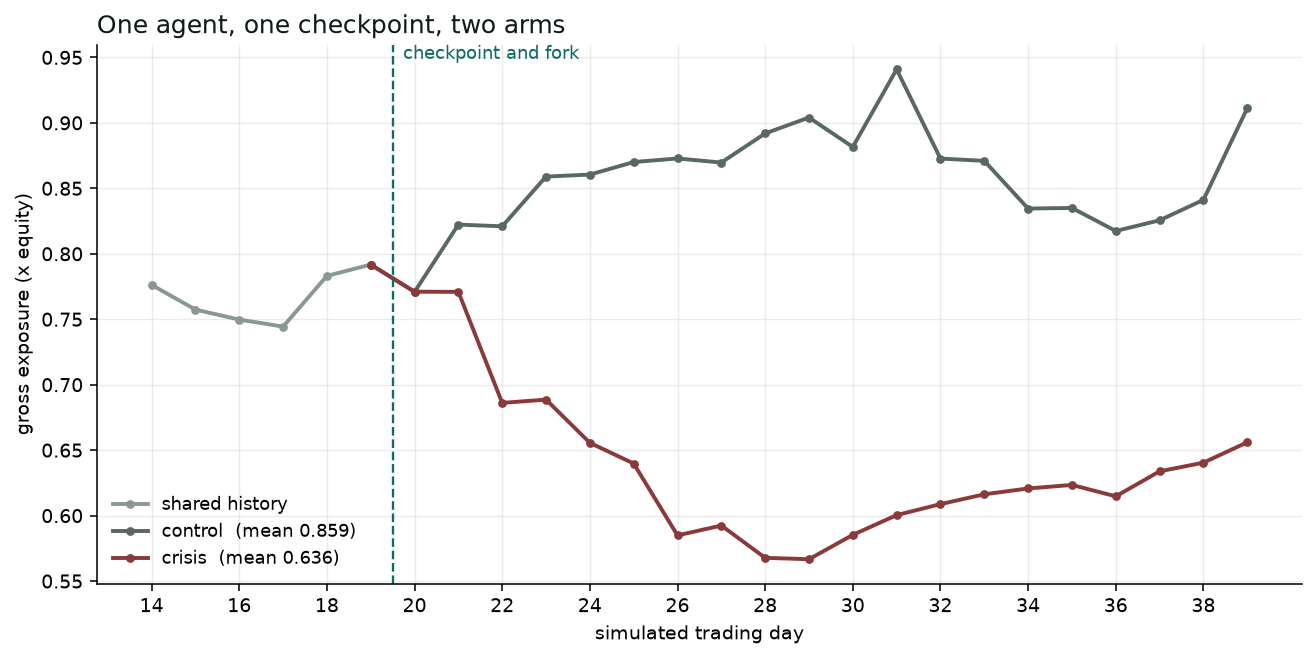

In [11]:
import matplotlib.pyplot as plt
import charts

shared = charts.shared_history(world, ex.WARMUP_DAYS,
                               ex.STEPS_PER_DAY)
charts.exposure_bands(series, bands, shared, ex.WARMUP_DAYS)
plt.show()

### What the agent did, with the market held still

Gross exposure moves for two reasons: the agent trades, and prices move
under a portfolio nobody touched. After the fork the arms trade different
markets, so the gap above is not by itself evidence that the agent did
anything.

So measure the agent's part alone. At each decision, gross exposure
immediately before its fills and immediately after, priced at the SAME
arrival prices. The market is held still and what is left is behaviour.

In [12]:
for name in names:
    row = bands[name]
    print(f"{name:>9}  agent moved exposure "
          f"{row['agent_change_total']:+.3f} over {row['decisions']} "
          f"decisions   ({row['agent_reductions']} down, "
          f"{row['agent_additions']} up)")

  control  agent moved exposure +0.122 over 20 decisions   (8 down, 12 up)
   crisis  agent moved exposure -0.128 over 20 decisions   (9 down, 11 up)


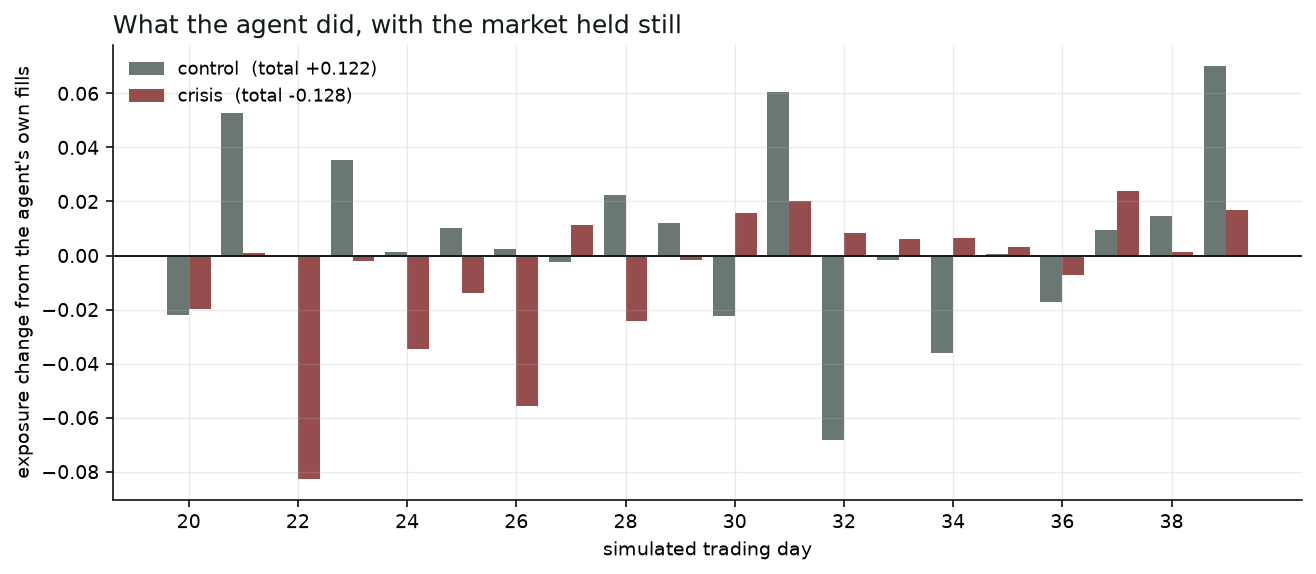

In [13]:
charts.agent_actions(series, bands)
plt.show()

In [14]:
print(f"expected ordering: {order['expected']}")
print(f"holds strictly on {order['strict']} of {order['days']} days")
print(f"days where it fails: {order['failures'] or 'none'}")
print(f"settled from day {order['settled_from_day']} onward")
print()
print(order["note"])

expected ordering: control > crisis
holds strictly on 19 of 20 days
days where it fails: [20]
settled from day 21 onward

consecutive days of one trajectory are not independent, so this is a description and not a significance test


## Check one: the same question asked again

Everything above is the canonical trajectory, one per arm. Before reading
the separation as a response, it needs something to be compared against.

Tradefloor removes every source of variation except one. The market is
deterministic, the arms share a history that `agree` verified, and the
prompts differ in the handful of lines printed above. So the only thing
left that can move is the agent itself, and the size of that is
measurable: ask each arm's fork-step question again, several times, and
look at the spread.

These are recorded, because a resample is N answers to one question and a
transcript holds one answer per question.

In [15]:
import json

recorded = json.loads((ex.HERE / "data" / "resample-fork.json")
                      .read_text(encoding="utf-8"))
stats = recorded["stats"]
print(f"n = {recorded['n']} per arm, {recorded['model']} at "
      f"temperature {recorded['temperature']}\n")
for name in names:
    row = stats[name]
    print(f"{name:<10} {row['distinct']}/{row['calls']} distinct answers   "
          f"net buys-sells {row['mean_net']:+.2f} "
          f"+/- {row['stdev_net']:.3f}")

print("\ngap from control, in units of the larger within-arm stdev:")
for name in ex.TREATMENTS:
    for field in ("net", "gross"):
        sep = ex.separation(stats, ex.CONTROL_ARM, name, field)
        print(f"  {name:<10} {field:<6} {sep['ratio']:+.2f}x noise")

n = 8 per arm, claude-sonnet-4-5-20250929 at temperature 0.0

control    4/8 distinct answers   net buys-sells +0.62 +/- 0.696
crisis     5/8 distinct answers   net buys-sells -0.12 +/- 0.599

gap from control, in units of the larger within-arm stdev:
  crisis     net    -1.08x noise
  crisis     gross  -1.94x noise


Every one of those ratios is inside the noise. Asked once, at the moment
the intervention lands, the crisis arm is not distinguishable from control.

The caution is concrete. An earlier pilot for this experiment produced a
first post-fork pair that read as a textbook result: on prompts
differing in two lines, the control arm bought a dip and the shocked arm
wrote *"reducing exposure ... to manage downside risk"*. Resampling showed
the split sat inside the control arm's own variance across eight identical
calls. It was one of four answers that arm gives to the same question.

That finding was on its way into a writeup. The resample is what stopped
it.

## Check two: run the whole thing again

The resample bounds one decision. It says nothing about the path, and the
bands are a property of the path.

So run the experiment again. The seed, the universe, the interventions and
the cadence are identical every time, which means the only thing that
varies between replications is the agent. That is the sample the "one
trajectory per arm" limit was asking for, and the determinism keeps it
clean: two replications differ by the agent and by nothing else.

Four replications, each a full twenty shared days and two twenty-day
arms, recorded live.

In [16]:
replications = json.loads((ex.HERE / "data" / "replications.json")
                          .read_text(encoding="utf-8"))

print(f"{replications['replications']} replications, "
      f"ordering holds on the means in "
      f"{replications['ordering_holds_on_means']}")
print()
print(f"{'run':>4}" + "".join(f"{n:>12}" for n in names) + "   ordering")
for row in replications["rows"]:
    print(f"{row['index']:>4}"
          + "".join(f"{row['mean_exposure'][n]:>12.3f}" for n in names)
          + f"   {row['ordering_strict']:>2}/{row['ordering_days']}"
          + ("  holds" if row["holds_on_means"] else "  FAILS"))
print()
for name in names:
    row = replications["per_arm"][name]
    print(f"{name:<10} mean of means {row['mean_of_means']:.3f} "
          f"+/- {row['stdev_of_means']:.3f}   "
          f"range {row['min']:.3f} to {row['max']:.3f}")

4 replications, ordering holds on the means in 3

 run     control      crisis   ordering
   1       0.772       0.635   17/20  holds
   2       0.916       0.725   20/20  holds
   3       0.790       0.627   20/20  holds
   4       0.637       0.646    8/20  FAILS

control    mean of means 0.779 +/- 0.099   range 0.637 to 0.916
crisis     mean of means 0.658 +/- 0.039   range 0.627 to 0.725


In [17]:
print("gap between adjacent arms, against the spread across replications:")
print()
for pair, row in replications["gaps"].items():
    ratio = "n/a" if row["ratio"] is None else f"{row['ratio']:.2f}x"
    print(f"  {pair:<22} gap {row['mean_gap']:+.3f}   "
          f"spread {row['spread']:.3f}   {ratio:>6} "
          f"   same sign in {row['positive_in']}/"
          f"{replications['replications']}")

gap between adjacent arms, against the spread across replications:

  control - crisis       gap +0.120   spread 0.099    1.21x    same sign in 3/4


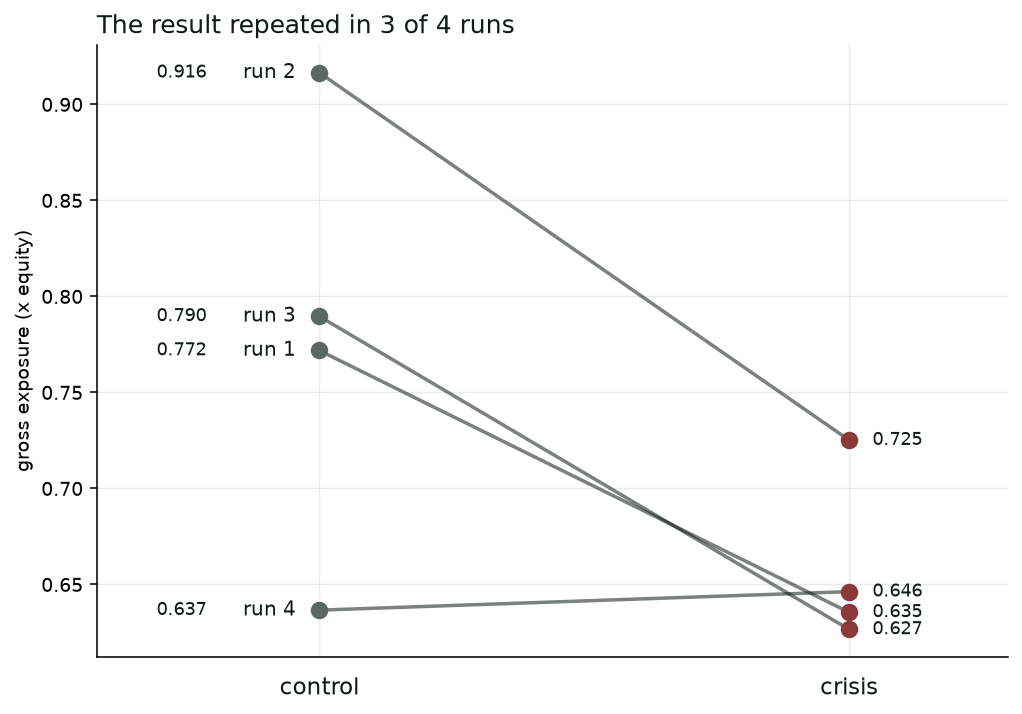

In [18]:
charts.replications(replications)
plt.show()

Crisis exposure was lower than its paired control in three of four runs.

Two observations about the fourth, without reading more into them. The
crisis values occupy a narrower range than the control values. And run 4's
crisis figure sits among the other crisis figures, while its control figure
sits below the other three controls.

## The rate shock that did not reproduce

Before the scenario, this experiment asked a narrower question with
hand-written macro moves: how much of the observation an intervention has
to change before the agent acts on it. Three arms -- control, a +200bps
move in the policy rate and the corporate yield, and that plus VIX 17 to 45
with the cycle phase moved to `contraction`.

The first run produced three cleanly separated exposure bands, ordered by
how loud the intervention was. It looked like a dose curve.

Four replications kept half of it. The rate-only arm reads 0.29 times the
between-replication spread and its sign flips: in one of four runs it
carried MORE exposure than control. The loud arm reads 1.85 times, with the
same sign every time.

That is the whole of the supporting story, and it is here for one reason: a
single convincing run is not a result. The numbers below are from those
recordings, replayed, not re-bought.

### Which part of the loud arm carried it

The loud arm moved four macro fields at once, so it cannot say which the
agent responded to. Two more arms split the regime half:

    vix      VIX 17 -> 45, and nothing else
    cycle    the cycle phase expansion -> contraction, and nothing else

Five arms from one fork. Every arm of a fork is bit-identical at the fork
whatever the arm count, so the recorded replications already cover the
shared history, control, +200bps and crisis, and only the two new arms
needed calling.

The two arms differ in a second way the numbers cannot separate. `cycle` is
a word and changes nothing else in the observation. `vix` is a number that
also widens spreads immediately, so that arm trades a rougher market as
well as reading a higher figure.

In [19]:
decomp = json.loads((ex.HERE / "data" / "decomposition.json")
                    .read_text(encoding="utf-8"))
arms5 = list(decomp["arms"])

print(f"{decomp['replications']} replications, five arms")
print()
for name in arms5:
    row = decomp["per_arm"][name]
    print(f"  {name:<10} {row['mean_of_means']:.3f} "
          f"+/- {row['stdev_of_means']:.3f}   "
          f"range {row['min']:.3f} to {row['max']:.3f}")

print()
print("against control, in units of the larger spread:")
print()
for name, row in decomp["against_control"].items():
    ratio = "n/a" if row["ratio"] is None else f"{row['ratio']:+.2f}x"
    print(f"  {name:<10} gap {row['gap']:+.3f}   "
          f"spread {row['spread']:.3f}   {ratio:>7}   "
          f"lower than control in {row['lower_in']}/"
          f"{decomp['replications']}")

4 replications, five arms

  control    0.776 +/- 0.054   range 0.683 to 0.815
  +200bps    0.754 +/- 0.077   range 0.657 to 0.872
  vix        0.669 +/- 0.114   range 0.558 to 0.852
  cycle      0.678 +/- 0.088   range 0.554 to 0.772
  crisis     0.612 +/- 0.044   range 0.561 to 0.662

against control, in units of the larger spread:

  +200bps    gap +0.022   spread 0.077    +0.29x   lower than control in 3/4
  vix        gap +0.107   spread 0.114    +0.94x   lower than control in 3/4
  cycle      gap +0.098   spread 0.088    +1.11x   lower than control in 4/4
  crisis     gap +0.164   spread 0.054    +3.02x   lower than control in 4/4


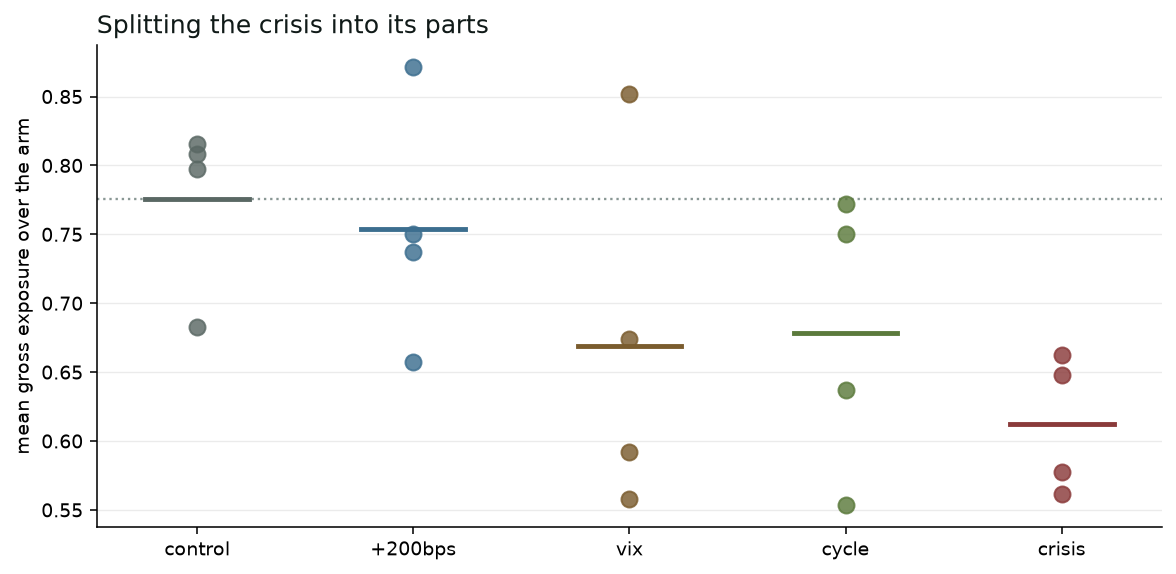

In [20]:
charts.decomposition(decomp)
plt.show()

Neither half reproduces the whole. `vix` reads 0.94 times its spread and is
lower than control in three replications of four. `cycle` reads 1.11 times
and is lower in four of four. Both spreads are about the size of their own
gaps, and in one replication the `vix` arm sat above control.

The combination reads 3.02 times, is lower in four of four, and has the
smallest spread of any arm at 0.044.

So the effect does not decompose at four replications. That is the finding,
and it is not an interaction claim: showing that two fields together do
something neither does alone needs more runs than this, and the numbers
above do not support it.

Two replications said something else. `vix` read 1.79 times there and
looked like the whole story. It was on its way into this notebook as one.

## The checks together

| | one decision | four replications |
|---|---|---|
| crisis, net direction | 1.08x the within-arm spread | |
| crisis, gross size | 1.94x | |
| mean exposure | | 1.21x, lower in 3 of 4 |

Every number here is above one and none is far above it.

The three checks answer different questions. Re-asking the exact same
fork-step question produced substantial variation, and the first decision
alone did not give us a clean answer. The canonical trajectory shows a
clear separation over twenty decisions, but its days are not independent
samples. The four live replications are the strongest check here, and the
direction held in three of them.

What the run supports: in the canonical trajectory the agent reduced gross
exposure in the crisis branch and increased it in control, the agent-only
measure attributes that to its trades rather than to prices, and across
four live repeats the crisis branch was lower in three.

The paths suggest why the first decision did not tell the whole story. The
agent adjusts at each decision rather than reacting once and holding, so a
single decision is a small step and twenty of them are the separation.

## Limits

- **Four replications, one market.** They all run the same market seed, so
  they resample the AGENT and not the market. Nothing here shows the result
  holds on a different market. Four is also not enough for a confidence
  interval, and none is quoted.
- **The days inside a run are autocorrelated.** Consecutive days of one
  trajectory are not independent observations, so a per-run ordering count
  is a description and not a significance test. The replication count is
  the number to read instead.
- **One model, one temperature.** `claude-sonnet-4-5-20250929` at
  temperature 0. Claude Opus 5 and Sonnet 5 have deprecated `temperature`
  and answer `400 invalid_request_error` to any explicit value, and
  `pyautogen` 0.2.35 sends one on every request. Those models run through
  FinRobot at the default of 1.0; what they cannot do is run at
  temperature 0, which is what a reproducible study wants.
- **One agent.** Everything here describes what FinRobot did. Another
  framework, or another mandate, is another experiment.
- **This universe is uncertified.** Twenty-four names is outside the roster
  Tradefloor's published realism envelope is measured on. The market is a
  valid Tradefloor market and it has not been measured against that
  envelope.
- **Risk language is counted, not read.** A regular expression counts
  decisions whose rationale contains one of a fixed list of words. In the
  canonical run that is 17 of 20 decisions in the crisis branch and 12 of
  20 in control. It is a difference in how often those words appear, and
  nothing about what the agent meant by them.
- **The scenario moves three targets at once.** Depth, volatility and the
  credit spread all change together, so which of them the agent responded
  to is unmeasured here. The supporting story above splits the older
  rate-and-regime arm and finds that neither half reproduces the whole,
  which is the same problem measured on a different treatment.
- **The credit widening is an assumption.** The scenario file labels it as
  one. Nothing in Tradefloor derives fifty basis points from a depth
  collapse, and a reader who disagrees can change the number and re-run.

## Reproduction

```bash
pip install tradefloor
git clone https://github.com/simoncoombes/tradefloor
cd tradefloor/examples/experiments/liquidity-crisis
jupyter lab notebook.ipynb
```

Or rebuild the notebook from the module, which is what produced the copy
committed here:

```bash
pip install matplotlib nbformat nbclient
python build_notebook.py
```

Either way it makes no model call, needs no API key and reaches no
network. Every decision the agent took was recorded once, live, and is
replayed from `tests/fixtures/finrobot/liquidity-crisis.json`.

## What is not here

This directory is the notebook and the module it imports. The runner, the
validator, the replication driver and the publication figures live in the
study repository this came from, along with the recorded runs of the
earlier +200bps experiment over 421 companies that this one grew out of.

What is here is enough to read the experiment, re-execute it, and check
every number in it against the recording.